# Обучение моделей, интерпретация и оценка бизнес-эффективности
В этом ноутбуке мы решаем проблему дисбаланса (сравниваем SMOTE и Class Weights), обучаем ансамбли деревьев, оптимизируем гиперпараметры и порог принятия решений, а также переводим метрики в реальные деньги.

In [1]:

import sys

sys.path.append('../')

import time
from collections import Counter

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import xgboost as xgb
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    auc,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)

from src.logger import get_logger

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

# Словари для хранения результатов
results_pr_auc = {}
results_f1 = {}
training_times = {}

logger = get_logger("Model_Training")

In [2]:
# Загружаем подготовленные данные
df = pd.read_parquet('../data/creditcard_processed.parquet')

X = df.drop('Class', axis=1)
y = df['Class']

# Стратифицированное разбиение данных (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

logger.info(f"Размер обучающей выборки: {X_train.shape}")
logger.info(f"Размер тестовой выборки: {X_test.shape}")

2026-08-27 17:51:53 | INFO     | Model_Training | Размер обучающей выборки: (227845, 31)
2026-08-27 17:51:53 | INFO     | Model_Training | Размер тестовой выборки: (56962, 31)


In [3]:
# --- Подход 1: SMOTE (Data-level approach) ---
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=RANDOM_STATE)
# Применяем ТОЛЬКО к тренировочной выборке для предотвращения утечки данных
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

logger.info(f"Исходное распределение: {Counter(y_train)}")
logger.info(f"Распределение после SMOTE: {Counter(y_train_res)}")

# --- Подход 2: Взвешивание классов (Algorithm-level approach) ---
N_total = len(y_train)
N_fraud = sum(y_train == 1)
N_legit = sum(y_train == 0)

scale_pos_weight_value = N_legit / N_fraud
logger.info(f"Значение scale_pos_weight для бустингов: {scale_pos_weight_value:.2f}")

2026-08-27 17:51:53 | INFO     | Model_Training | Исходное распределение: Counter({0: 227451, 1: 394})
2026-08-27 17:51:53 | INFO     | Model_Training | Распределение после SMOTE: Counter({0: 227451, 1: 227451})
2026-08-27 17:51:53 | INFO     | Model_Training | Значение scale_pos_weight для бустингов: 577.29


In [4]:
def evaluate_model(y_true, y_pred, y_prob, model_name="Model"):
    """Расчет метрик, построение матрицы ошибок и PR-кривой"""
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)
    
    logger.info(f"[{model_name}] PR-AUC: {pr_auc:.4f} | F1: {f1:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f}")
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Матрица ошибок
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
    axes[0].set_title('Confusion Matrix')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')
    
    # PR-кривая
    axes[1].plot(recall_curve, precision_curve, label=f'PR-AUC = {pr_auc:.4f}', color='red')
    axes[1].set_xlabel('Recall')
    axes[1].set_ylabel('Precision')
    axes[1].set_title('Precision-Recall Curve')
    axes[1].legend(loc="lower left")
    
    plt.tight_layout()
    plt.show()
    
    return pr_auc, f1

2026-08-27 17:51:54 | INFO     | Model_Training | [Logistic Regression (SMOTE)] PR-AUC: 0.7602 | F1: 0.1025 | Precision: 0.0543 | Recall: 0.9082


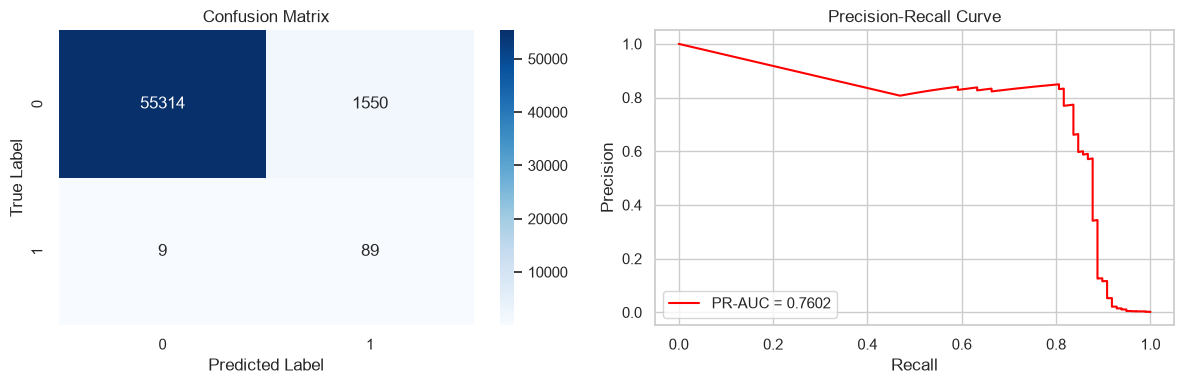

2026-08-27 17:51:54 | INFO     | Model_Training | [Logistic Regression (Class Weights)] PR-AUC: 0.7547 | F1: 0.1076 | Precision: 0.0572 | Recall: 0.9082


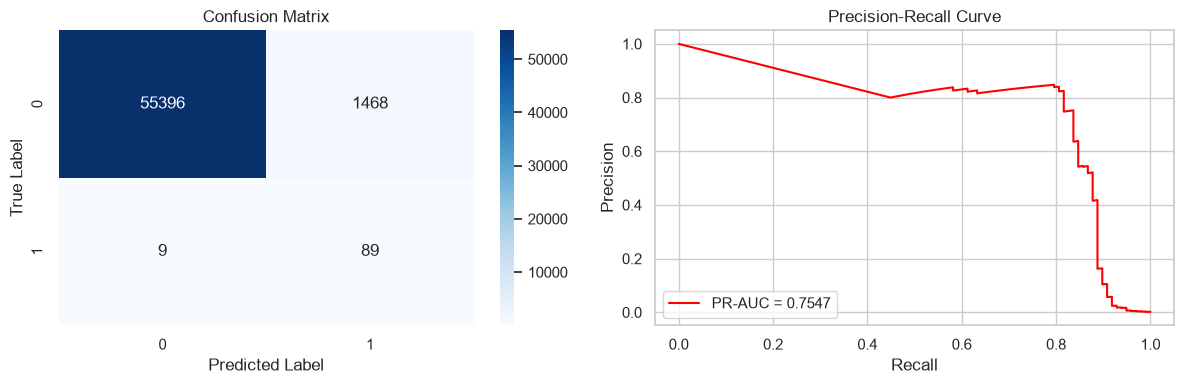

(0.7546747878407271, 0.10755287009063444)

In [5]:
# ==========================================
# БАЗОВЫЕ МОДЕЛИ: Логистическая Регрессия
# ==========================================

# 1. LR + SMOTE
lr_smote = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_smote.fit(X_train_res, y_train_res)
evaluate_model(y_test, lr_smote.predict(X_test), lr_smote.predict_proba(X_test)[:, 1], "Logistic Regression (SMOTE)")

# 2. LR + Class Weights
lr_weight = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_weight.fit(X_train, y_train)
evaluate_model(y_test, lr_weight.predict(X_test), lr_weight.predict_proba(X_test)[:, 1], "Logistic Regression (Class Weights)")

2026-08-27 17:51:56 | INFO     | Model_Training | [XGBoost (SMOTE)] PR-AUC: 0.8654 | F1: 0.8485 | Precision: 0.8400 | Recall: 0.8571


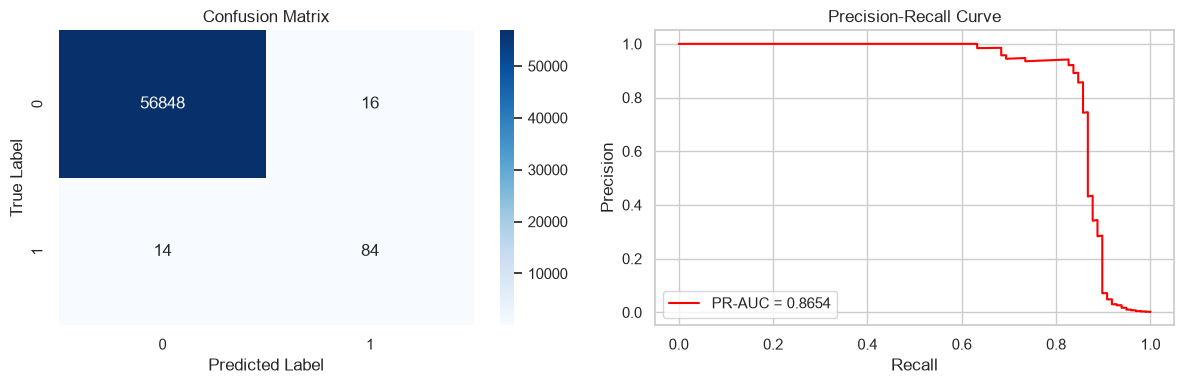

2026-08-27 17:51:56 | INFO     | Model_Training | [XGBoost (Class Weights)] PR-AUC: 0.8637 | F1: 0.8511 | Precision: 0.8889 | Recall: 0.8163


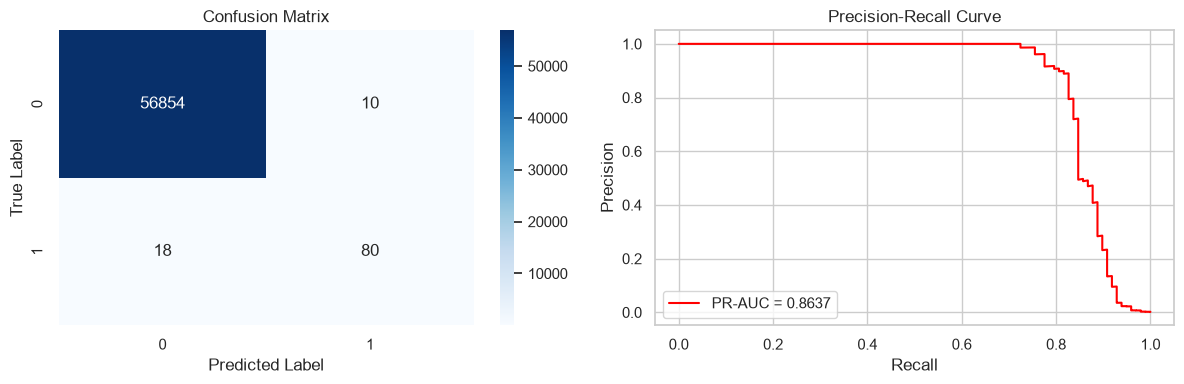

In [6]:
# ==========================================
# АНСАМБЛЕВЫЕ МОДЕЛИ
# ==========================================

# --- XGBoost ---
# SMOTE
start_time = time.time()
xgb_smote = xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='aucpr')
xgb_smote.fit(X_train_res, y_train_res)
t = time.time() - start_time
p, f = evaluate_model(y_test, xgb_smote.predict(X_test), xgb_smote.predict_proba(X_test)[:, 1], "XGBoost (SMOTE)")
results_pr_auc['XGB_SMOTE'] = p; results_f1['XGB_SMOTE'] = f; training_times['XGB_SMOTE'] = t

# Weights
start_time = time.time()
xgb_weight = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_STATE, eval_metric='aucpr')
xgb_weight.fit(X_train, y_train)
t = time.time() - start_time
p, f = evaluate_model(y_test, xgb_weight.predict(X_test), xgb_weight.predict_proba(X_test)[:, 1], "XGBoost (Class Weights)")
results_pr_auc['XGB_Weights'] = p; results_f1['XGB_Weights'] = f; training_times['XGB_Weights'] = t

2026-08-27 17:51:58 | INFO     | Model_Training | [LightGBM (SMOTE)] PR-AUC: 0.8354 | F1: 0.7328 | Precision: 0.6343 | Recall: 0.8673


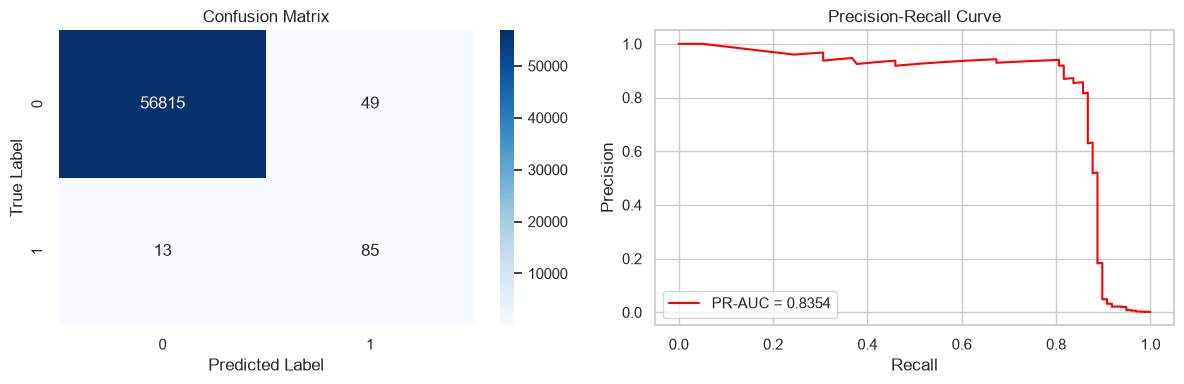

2026-08-27 17:51:59 | INFO     | Model_Training | [LightGBM (Class Weights - Collapse)] PR-AUC: 0.4516 | F1: 0.0528 | Precision: 0.0272 | Recall: 0.8776


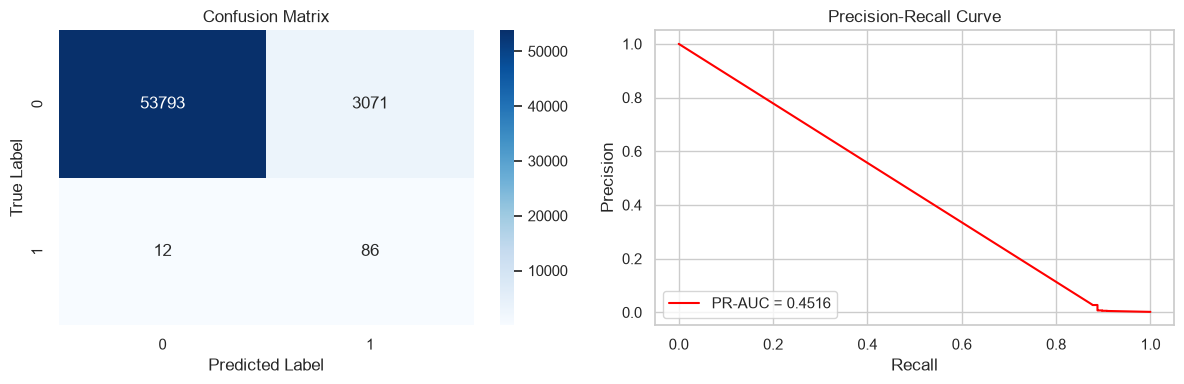

2026-08-27 17:51:59 | INFO     | Model_Training | [LightGBM (Class Weights & Regularized)] PR-AUC: 0.4566 | F1: 0.0609 | Precision: 0.0315 | Recall: 0.8776


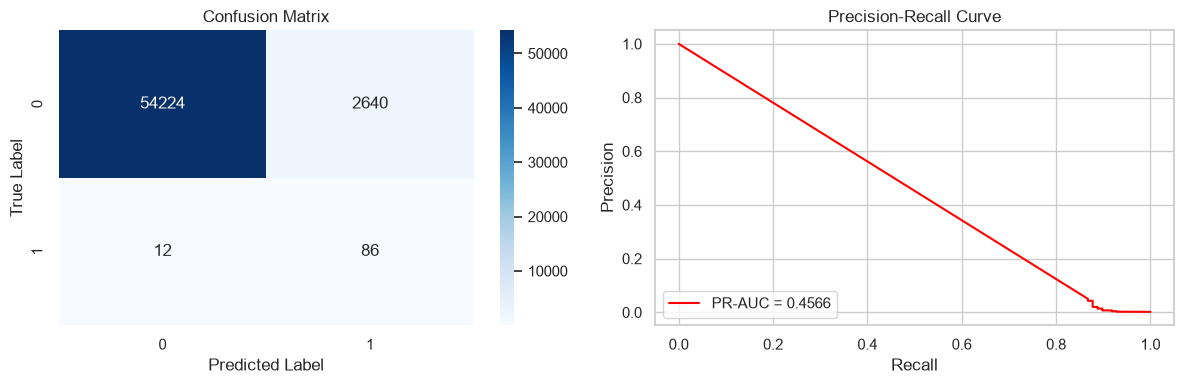

In [7]:
# --- LightGBM ---
# SMOTE
start_time = time.time()
lgb_smote = lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)
lgb_smote.fit(X_train_res, y_train_res)
t = time.time() - start_time
p, f = evaluate_model(y_test, lgb_smote.predict(X_test), lgb_smote.predict_proba(X_test)[:, 1], "LightGBM (SMOTE)")
results_pr_auc['LGB_SMOTE'] = p; results_f1['LGB_SMOTE'] = f; training_times['LGB_SMOTE'] = t

# Weights (с проблемой коллапса вероятностей)
start_time = time.time()
lgb_weight_raw = lgb.LGBMClassifier(is_unbalance=True, random_state=RANDOM_STATE, verbose=-1)
lgb_weight_raw.fit(X_train, y_train)
t = time.time() - start_time
p, f = evaluate_model(y_test, lgb_weight_raw.predict(X_test), lgb_weight_raw.predict_proba(X_test)[:, 1], "LightGBM (Class Weights - Collapse)")
results_pr_auc['LGB_Weights_Raw'] = p; results_f1['LGB_Weights_Raw'] = f; training_times['LGB_Weights_Raw'] = t

# Weights (Регуляризированный)
start_time = time.time()
lgb_weight_reg = lgb.LGBMClassifier(is_unbalance=True, max_depth=4, num_leaves=10, min_child_samples=50, random_state=RANDOM_STATE, verbose=-1)
lgb_weight_reg.fit(X_train, y_train)
t = time.time() - start_time
p, f = evaluate_model(y_test, lgb_weight_reg.predict(X_test), lgb_weight_reg.predict_proba(X_test)[:, 1], "LightGBM (Class Weights & Regularized)")
results_pr_auc['LGB_Weights_Reg'] = p; results_f1['LGB_Weights_Reg'] = f; training_times['LGB_Weights_Reg'] = t

2026-08-27 17:52:18 | INFO     | Model_Training | [CatBoost (SMOTE)] PR-AUC: 0.8568 | F1: 0.7962 | Precision: 0.7434 | Recall: 0.8571


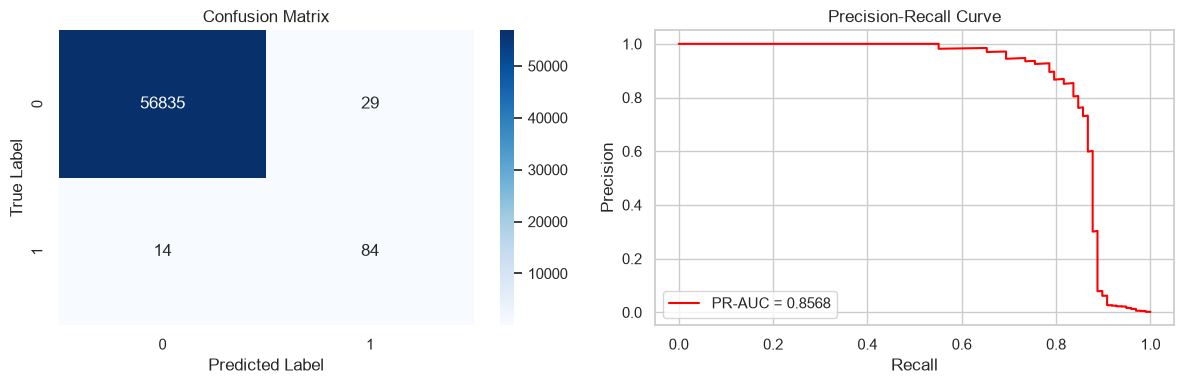

2026-08-27 17:52:27 | INFO     | Model_Training | [CatBoost (Class Weights)] PR-AUC: 0.8530 | F1: 0.8000 | Precision: 0.7500 | Recall: 0.8571


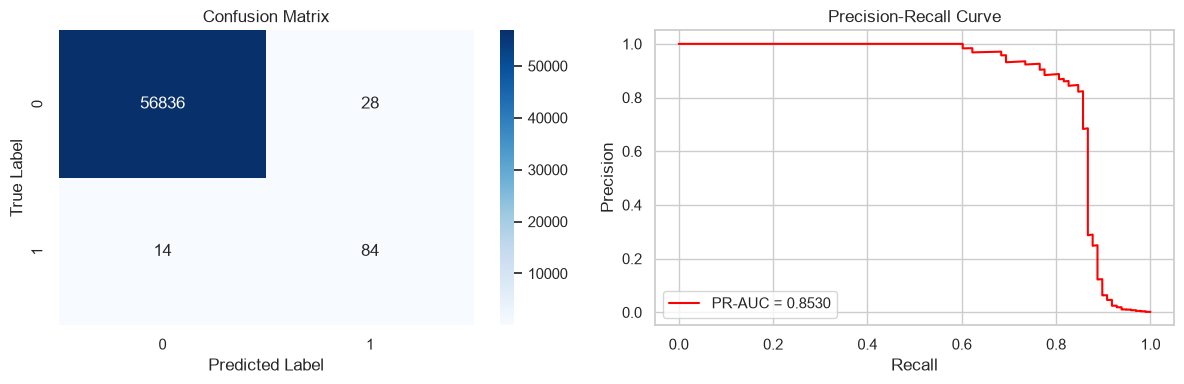

In [8]:
# --- CatBoost ---
# SMOTE
start_time = time.time()
cat_smote = CatBoostClassifier(random_state=RANDOM_STATE, eval_metric='AUC', verbose=0)
cat_smote.fit(X_train_res, y_train_res)
t = time.time() - start_time
p, f = evaluate_model(y_test, cat_smote.predict(X_test), cat_smote.predict_proba(X_test)[:, 1], "CatBoost (SMOTE)")
results_pr_auc['CAT_SMOTE'] = p; results_f1['CAT_SMOTE'] = f; training_times['CAT_SMOTE'] = t

# Weights
start_time = time.time()
cat_weight = CatBoostClassifier(auto_class_weights='Balanced', random_state=RANDOM_STATE, eval_metric='AUC', verbose=0)
cat_weight.fit(X_train, y_train)
t = time.time() - start_time
p, f = evaluate_model(y_test, cat_weight.predict(X_test), cat_weight.predict_proba(X_test)[:, 1], "CatBoost (Class Weights)")
results_pr_auc['CAT_Weights'] = p; results_f1['CAT_Weights'] = f; training_times['CAT_Weights'] = t

In [9]:
# Итоги сравнения алгоритмов
summary_df = pd.DataFrame({
    'PR-AUC': results_pr_auc,
    'F1-score (thr=0.5)': results_f1,
    'Время обучения (сек)': training_times
})
print("Сравнительная таблица:")
display(summary_df.sort_values(by='PR-AUC', ascending=False))

Сравнительная таблица:


,PR-AUC,F1-score (thr=0.5),Время обучения (сек)
XGB_SMOTE,0.865373,0.848485,1.168199
XGB_Weights,0.863665,0.851064,0.506338
CAT_SMOTE,0.856802,0.796209,17.858919
CAT_Weights,0.852975,0.800000,9.349141
LGB_SMOTE,0.835403,0.732759,1.222703
LGB_Weights_Reg,0.456619,0.060907,0.461976
LGB_Weights_Raw,0.451613,0.052842,0.616273


## Настройка гиперпараметров и оптимизация порога (XGBoost)
Победитель: **XGBoost + Class Weights**. Оттюнингуем его и подберем идеальный бизнес-порог.

2026-08-27 17:52:30 | INFO     | Model_Training | [XGBoost (Tuned)] PR-AUC: 0.8739 | F1: 0.8526 | Precision: 0.8804 | Recall: 0.8265


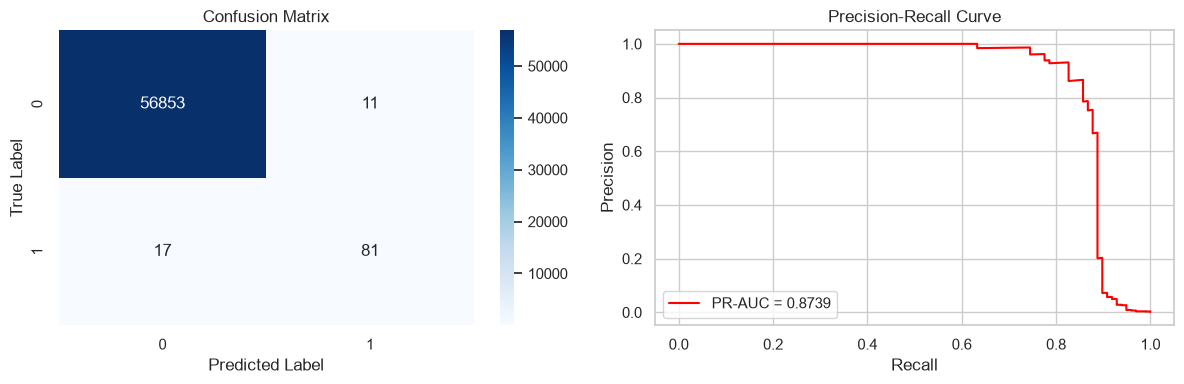

(0.8738796032390975, 0.8526315789473684)

In [10]:
# Тюнинг XGBoost (Закомментировано для быстрого запуска, используем готовые лучшие параметры)
"""
param_grid = {
    'max_depth': [3, 5, 6, 8, 10],            
    'learning_rate': [0.05, 0.1, 0.2, 0.3],   
    'n_estimators': [100, 200, 300, 500],     
    'subsample': [0.7, 0.8, 1.0],             
    'colsample_bytree': [0.7, 0.8, 1.0],      
    'gamma': [0, 0.1, 0.5, 1.0]               
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
xgb_base = xgb.XGBClassifier(scale_pos_weight=scale_pos_weight_value, random_state=RANDOM_STATE, eval_metric='aucpr')
random_search = RandomizedSearchCV(xgb_base, param_grid, n_iter=100, scoring='average_precision', cv=cv, n_jobs=-1, random_state=RANDOM_STATE)
random_search.fit(X_train, y_train)
best_model = random_search.best_estimator_
"""

# Инициализируем модель с лучшими параметрами (из логов)
best_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight_value,
    subsample=0.8, n_estimators=500, max_depth=10, 
    learning_rate=0.2, gamma=0, colsample_bytree=0.7,
    random_state=RANDOM_STATE, eval_metric='aucpr'
)
best_model.fit(X_train, y_train)

y_prob_tuned = best_model.predict_proba(X_test)[:, 1]
evaluate_model(y_test, best_model.predict(X_test), y_prob_tuned, "XGBoost (Tuned)")

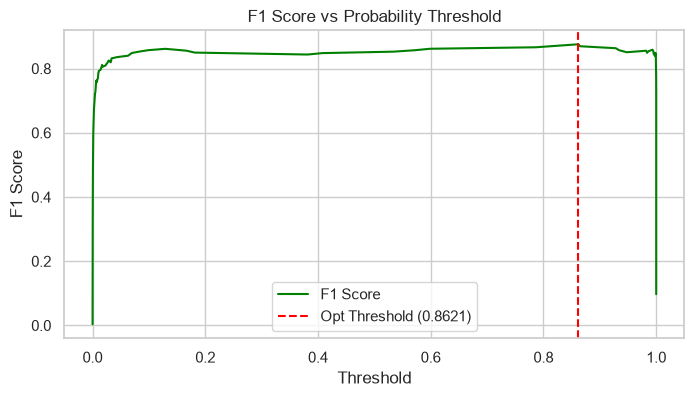

2026-08-27 17:52:30 | INFO     | Model_Training | Метрики XGBoost с оптимальным порогом (0.8621):
2026-08-27 17:52:30 | INFO     | Model_Training | F1: 0.8757, Precision: 0.9310, Recall: 0.8265


In [11]:
def optimize_threshold(y_true, y_prob):
    precision_curve, recall_curve, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, f1_scores[:-1], label='F1 Score', color='green')
    plt.axvline(x=optimal_threshold, color='red', linestyle='--', label=f'Opt Threshold ({optimal_threshold:.4f})')
    plt.title('F1 Score vs Probability Threshold')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.legend()
    plt.show()
    
    return optimal_threshold

best_threshold_xgb = optimize_threshold(y_test, y_prob_tuned)
y_pred_optimal = (y_prob_tuned >= best_threshold_xgb).astype(int)

logger.info(f"Метрики XGBoost с оптимальным порогом ({best_threshold_xgb:.4f}):")
logger.info(f"F1: {f1_score(y_test, y_pred_optimal):.4f}, Precision: {precision_score(y_test, y_pred_optimal):.4f}, Recall: {recall_score(y_test, y_pred_optimal):.4f}")

SHAP Summary Plot:


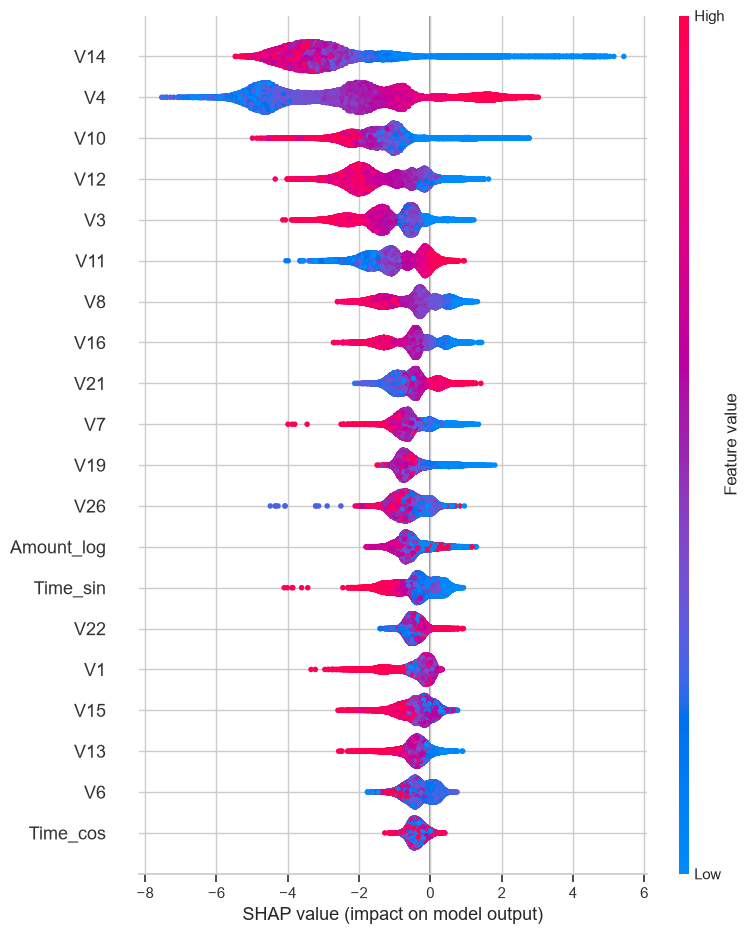

In [12]:
# --- Интерпретация SHAP ---
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

print("SHAP Summary Plot:")
shap.summary_plot(shap_values, X_test, plot_type="dot")

In [13]:
# --- Экономическая эффективность ---
COST_OF_INVESTIGATION = 10  # Затраты на проверку ложной тревоги

# Подтягиваем оригинальные суммы транзакций из исходного CSV для точности
df_orig = pd.read_csv('../data/creditcard.csv')
amounts_original = df_orig.loc[X_test.index, 'Amount'].values

def calculate_financial_impact(y_true, y_pred, amounts):
    # Стоимость пропущенного мошенничества
    missed_fraud_cost = amounts[(y_true == 1) & (y_pred == 0)].sum()
    
    # Стоимость разбора ложных срабатываний
    investigation_cost = sum((y_true == 0) & (y_pred == 1)) * COST_OF_INVESTIGATION
    
    # Предотвращенный ущерб
    saved_money = amounts[(y_true == 1) & (y_pred == 1)].sum()
    
    logger.info(f"Предотвращенный ущерб (TP): ${saved_money:,.2f}")
    logger.info(f"Потери от пропущенного фрода (FN): ${missed_fraud_cost:,.2f}")
    logger.info(f"Затраты на ложные тревоги (FP): ${investigation_cost:,.2f}")
    if investigation_cost > 0:
        logger.info(f"Возврат инвестиций (ROI): {((saved_money - investigation_cost) / investigation_cost) * 100:.2f}%")
    logger.info(f"ИТОГОВАЯ ВЫГОДА: ${saved_money - investigation_cost:,.2f}\\n")

logger.info("=== Экономика ДО оптимизации порога (p=0.5) ===")
calculate_financial_impact(y_test, best_model.predict(X_test), amounts_original)

logger.info(f"=== Экономика ПОСЛЕ оптимизации порога (p={best_threshold_xgb:.4f}) ===")
calculate_financial_impact(y_test, y_pred_optimal, amounts_original)

2026-08-27 17:52:37 | INFO     | Model_Training | === Экономика ДО оптимизации порога (p=0.5) ===
2026-08-27 17:52:37 | INFO     | Model_Training | Предотвращенный ущерб (TP): $8,700.83
2026-08-27 17:52:37 | INFO     | Model_Training | Потери от пропущенного фрода (FN): $1,944.10
2026-08-27 17:52:37 | INFO     | Model_Training | Затраты на ложные тревоги (FP): $110.00
2026-08-27 17:52:37 | INFO     | Model_Training | Возврат инвестиций (ROI): 7809.85%
2026-08-27 17:52:37 | INFO     | Model_Training | ИТОГОВАЯ ВЫГОДА: $8,590.83\n
2026-08-27 17:52:37 | INFO     | Model_Training | === Экономика ПОСЛЕ оптимизации порога (p=0.8621) ===
2026-08-27 17:52:37 | INFO     | Model_Training | Предотвращенный ущерб (TP): $8,700.83
2026-08-27 17:52:37 | INFO     | Model_Training | Потери от пропущенного фрода (FN): $1,944.10
2026-08-27 17:52:37 | INFO     | Model_Training | Затраты на ложные тревоги (FP): $60.00
2026-08-27 17:52:37 | INFO     | Model_Training | Возврат инвестиций (ROI): 14401.38%
202